# LSTM Model for Vehicle Collisions

## Import Required Libraries

In [105]:
# Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from tqdm import tqdm

## Extract Features from Each Frame

In [106]:
# extract features from the CSV file
def extract_frame_features(frame_df):
    num_objects = len(frame_df)
    avg_conf = frame_df["confidence"].mean()
    avg_box_area = ((frame_df["x_max"] - frame_df["x_min"]) *
                    (frame_df["y_max"] - frame_df["y_min"])).mean()

    desired_size = 13
    class_counts = np.zeros(desired_size)

    for cls in frame_df["object_class"]:
        cls = int(cls)
        if cls < desired_size:
            class_counts[cls] += 1

    return torch.tensor([num_objects, avg_conf, avg_box_area] + class_counts.tolist(), dtype=torch.float32)

# Process the CSV file and extract features for each frame
def process_video_csv(csv_path):
    df = pd.read_csv(csv_path)

    if df.empty or "frame" not in df.columns:
        #print(f"Empty or invalid CSV: {csv_path}")
        return None
    
    sequences = []
    for _, frame_df in df.groupby("frame"):
        frame_feat = extract_frame_features(frame_df)
        sequences.append(frame_feat)

    return torch.stack(sequences) 



## Load Data Labels/Targets

In [107]:
import csv

# Load label CSV into a dictionary
label_dict = {}
with open("../data/train_labels.csv", newline = "") as f:
    reader = csv.DictReader(f)
    for row in reader:
        label_dict[row["id"]] = int(row["target"])

## Split Data into Training, Validation, and Test Sets

In [108]:
from sklearn.model_selection import train_test_split

# Get all video directories
video_dirs = sorted([
    os.path.join("../data/yolo_processed_data", d)
    for d in os.listdir("../data/yolo_processed_data")
    if os.path.isdir(os.path.join("../data/yolo_processed_data", d))
])

# Initialize an empty list to store video_ids
video_ids = []

# Extract video IDs from the directory names, removing video_ prefix
for video_dir in video_dirs:
    video_id = os.path.basename(video_dir).replace("video_", "")
    video_ids.append(video_id)

# Ensure there are labels for all video IDs
for video_id in video_ids:
    if video_id not in label_dict:
        raise AssertionError(f"Label missing for video: {video_id}")



# Split the video IDs
train_ids, temp_ids = train_test_split(video_ids, test_size = 0.2)
val_ids, test_ids = train_test_split(temp_ids, test_size = 0.5)


# Initialize empty lists to store the video directories
train_videos = []
val_videos = []
test_videos = []

# Populate the train_videos list with the corresponding directories
for video_id in train_ids:
    video_dir = os.path.join("../data/yolo_processed_data", "video_" + video_id)
    train_videos.append(video_dir)

# Populate the val_videos list with the corresponding directories
for video_id in val_ids:
    video_dir = os.path.join("../data/yolo_processed_data", "video_" + video_id)
    val_videos.append(video_dir)

# Populate the test_videos list with the corresponding directories
for video_id in test_ids:
    video_dir = os.path.join("../data/yolo_processed_data", "video_" + video_id)
    test_videos.append(video_dir)

In [109]:
# Shape Sanity Check
print(f"-----Dataset Sizes-----")
print(f"Total Video Count: {len(video_dirs)}")
print(f"Train videos: {len(train_videos)} Videos | {(len(train_videos) / len(video_dirs)) * 100}%")
print(f"Validation videos: {len(val_videos)} Videos | {(len(val_videos) / len(video_dirs)) * 100}%")
print(f"Test videos: {len(test_videos)} Videos | {(len(test_videos) / len(video_dirs)) * 100}%\n")


print(f"-----Sample Dataset Values-----")
print(f"Train Videos: {train_videos[0:2]}")
print(f"Validation Videos: {val_videos[0:2]}")
print(f"Test Videos: {test_videos[0:2]}")

-----Dataset Sizes-----
Total Video Count: 1500
Train videos: 1200 Videos | 80.0%
Validation videos: 150 Videos | 10.0%
Test videos: 150 Videos | 10.0%

-----Sample Dataset Values-----
Train Videos: ['../data/yolo_processed_data\\video_00311', '../data/yolo_processed_data\\video_00660']
Validation Videos: ['../data/yolo_processed_data\\video_01527', '../data/yolo_processed_data\\video_00901']
Test Videos: ['../data/yolo_processed_data\\video_01983', '../data/yolo_processed_data\\video_00584']


## Create Dataset and DataLoader

In [110]:
# Create a dataset class for the video sequences
class VideoDataset(Dataset):
    def __init__(self, video_dirs, label_dict):
        self.video_dirs = video_dirs
        self.label_dict = label_dict

    def __len__(self):
        return len(self.video_dirs)
    
    def __getitem__(self, idx):
        while True:
            video_dir = self.video_dirs[idx]
            video_id = os.path.basename(video_dir)
            
            if video_id.startswith("video_"):
                video_id = video_id.replace("video_", "")

            video_id = video_id.zfill(5)

            label = self.label_dict.get(video_id, 0)

            csv_path = os.path.join(video_dir, "detections.csv")
            seq = process_video_csv(csv_path)

            if seq is None:
                idx = (idx + 1) % len(self.video_dirs)
                return self.__getitem__(idx)

            return seq, torch.tensor(label, dtype = torch.float32)
    
    
# Collate function to pad sequences and create batches
def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = [len(seq) for seq in sequences]  # Get the sequence lengths
    padded = pad_sequence(sequences, batch_first = True, padding_value = 0)  # Pad sequences with zero padding
    
    return padded, torch.tensor(lengths), torch.tensor(labels)


# Create datasets for training and validation
train_dataset = VideoDataset(train_videos, label_dict)
val_dataset = VideoDataset(val_videos, label_dict)
test_dataset = VideoDataset(test_videos, label_dict)

# Create DataLoader objects for training, validation, and testing
train_loader = DataLoader(train_dataset, batch_size = 4, shuffle = True, collate_fn = collate_fn)
val_loader = DataLoader(val_dataset, batch_size = 4, shuffle = False, collate_fn = collate_fn)
test_loader = DataLoader(test_dataset, batch_size = 4, shuffle = False, collate_fn = collate_fn)

## Define the LSTM Model

In [111]:
# Define the LSTM model for classification  
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers = 1, dropout = 0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers = num_layers,
                            dropout = dropout if num_layers > 1 else 0.0,
                            batch_first = True, bidirectional = True)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first = True, enforce_sorted = False)
        _, (hn, _) = self.lstm(packed)
        out = self.fc(hn[-1])
        
        return self.sigmoid(out).squeeze()

## Training Loop

In [112]:
def train_model(model, train_loader, val_loader, criterion, optimizer, patience, device, epochs):
    model.to(device)

    # Initialize a previous loss value as a variable to compare validation losses to after each iteration
    previous_val_loss = float("inf")

    # Initialize loss lists and early stopping epochs
    train_losses = []
    val_losses = []
    early_stopping_epochs = 0

    # Iterate through epochs
    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_train_loss = 0

        for x_batch, lengths, y_batch in train_loader:
            x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch, lengths)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Phase
        model.eval()
        running_val_loss = 0

        with torch.no_grad():
            for x_val, val_lengths, y_val in val_loader:
                x_val, val_lengths, y_val = x_val.to(device), val_lengths.to(device), y_val.to(device)

                val_outputs = model(x_val, val_lengths)
                val_loss = criterion(val_outputs, y_val)

                running_val_loss += val_loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        #print(f"Epoch {epoch + 1}: Train Loss = {avg_train_loss} | Val Loss = {avg_val_loss}")

        # Early stop if validation loss change is below tolerance
        if previous_val_loss > avg_val_loss:
            previous_val_loss = avg_val_loss
            early_stopping_epochs = 0
        else:
            early_stopping_epochs += 1

        # Break the loop if early stopping criteria is met
        if early_stopping_epochs >= patience:
            #print("Early stopping triggered.")
            break

    return train_losses, val_losses


## Tune Hyperparameters

In [115]:
# Function to iterate through differnt combinations of hyperparameters
def tune_lstm_hyperparameters(train_loader, val_loader, params, input_size, epochs, patience):
    best_params = None
    best_val_loss = float("inf")
    results = []

    # Calculate total combinations
    total_combinations = (
        len(params["hidden_size"]) *
        len(params["num_layers"]) *
        len(params["dropout"]) *
        len(params["learning_rate"]) *
        len(params["optimizer"])
    )

    with tqdm(total = total_combinations, desc = "Tuning") as progressbar:
        for hidden_size in tqdm(params["hidden_size"]):
            for dropout in params["dropout"]:
                for learning_rate in params["learning_rate"]:
                    for num_layers in params["num_layers"]:
                        for optimizer_name in params["optimizer"]:
                            
                            # Initialize the LSTM model with the current parameter combinations
                            model = LSTMClassifier(input_size = input_size,
                                                hidden_size = hidden_size,
                                                num_layers = num_layers,
                                                dropout = dropout)
                            
                            # Select the appropriate optimizer
                            if optimizer_name == "adam":
                                optimizer = optim.Adam(model.parameters(), lr = learning_rate)
                            elif optimizer_name == "rmsprop":
                                optimizer = optim.RMSprop(model.parameters(), lr = learning_rate)
                            else:
                                continue
                            
                            # Define criterion (loss function) and device
                            criterion = nn.BCELoss()
                            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
                            
                            # Train the model
                            train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, patience, device, epochs)
                            final_val_loss = val_losses[-1] if val_losses else float("inf")


                            # Append results of the run to the dictionary
                            results.append({
                                "hidden_size": hidden_size,
                                "dropout": dropout,
                                "learning_rate": learning_rate,
                                "num_layers": num_layers,
                                "optimizer": optimizer_name,
                                "final_val_loss": final_val_loss
                            })


                            # Store the current parameters if they produce a lower val loss than the previous best
                            if final_val_loss < best_val_loss:
                                best_val_loss = final_val_loss
                                best_params = {
                                    "hidden_size": hidden_size,
                                    "dropout": dropout,
                                    "learning_rate": learning_rate,
                                    "num_layers": num_layers,
                                    "optimizer": optimizer_name
                                }


                            # Update progress bar
                            progressbar.update(1)

    print("Best Hyperparameters:", best_params)
    print("Best Validation Loss:", best_val_loss)
    
    return best_params, results

"""
params = {
    "hidden_size": [64, 128, 256],
    "dropout": [0.3, 0.4],
    "learning_rate": [0.001, 0.0001],
    "num_layers": [1, 2, 3],
    "optimizer": ["adam", "rmsprop"]
}
"""

params = {
    "hidden_size": [512],
    "dropout": [0.3, 0.4],
    "learning_rate": [0.001],
    "num_layers": [3],
    "optimizer": ["adam", "rmsprop"]
}

input_size = 16
epochs = 30
patience = 5

best_params, results = tune_lstm_hyperparameters(train_loader, val_loader, params, input_size, epochs, patience)


Tuning: 100%|██████████| 4/4 [2:48:03<00:00, 2520.94s/it]

Best Hyperparameters: {'hidden_size': 512, 'dropout': 0.3, 'learning_rate': 0.001, 'num_layers': 3, 'optimizer': 'adam'}
Best Validation Loss: 0.6942965670635826


## Plot the Training and Validation Loss Curves for the Optimal Model

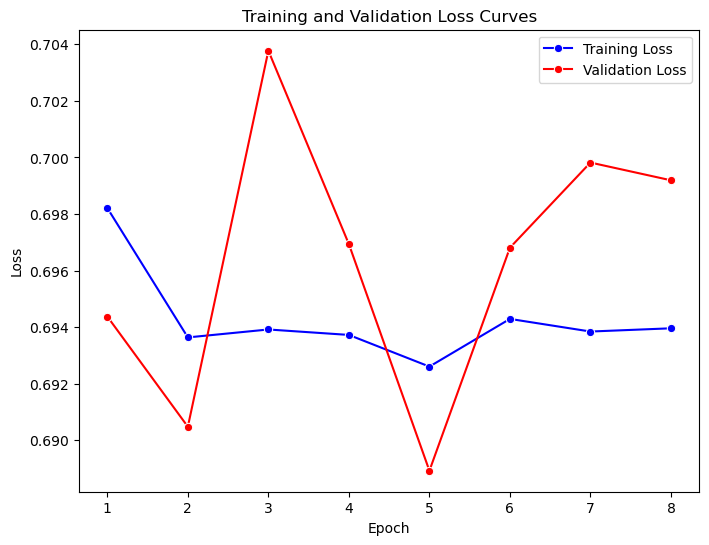

In [116]:
# Intialize the model with the tuned optimal parameters
model = LSTMClassifier(input_size = input_size, hidden_size = best_params["hidden_size"], num_layers = best_params["num_layers"], dropout = best_params["dropout"])


# Identify the optimal optimizer
if best_params["optimizer"] == "adam":
    optimizer = optim.Adam(model.parameters(), lr = best_params["learning_rate"])
    
elif best_params["optimizer"] == "rmsprop":
    optimizer = optim.RMSprop(model.parameters(), lr = best_params["learning_rate"])


# Determine number of epochs, level of patience, loss function, and device
input_size = 16
epochs = 100
patience = 3
criterion = nn.BCELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Train the optimal model
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, patience, device, epochs)


# Plot training and validation losses after all epochs are finished
plt.figure(figsize = (8, 6))
sns.lineplot(x = range(1, len(train_losses) + 1), y = train_losses, label = "Training Loss", marker = "o", linestyle = "-", color = "blue")
sns.lineplot(x = range(1, len(val_losses) + 1), y = val_losses, label = "Validation Loss", marker = "o", linestyle = "-", color = "red")
plt.title("Training and Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Evaluate the Test Set

In [117]:
def evaluate_model(model, test_loader, device, criterion):
    model.eval()

    total_test_loss = 0.0
    all_preds_percentage = []
    all_labels = []


    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for x_batch, lengths, y_batch in test_loader:
            x_batch, lengths = x_batch.to(device), lengths.to(device)

            outputs = model(x_batch, lengths)
            loss = criterion(outputs, y_batch)
            total_test_loss += loss.item() * x_batch.size(0)

            # Threshold at 0.5 for binary classification
            #preds = (outputs >= 0.5).float()  

            all_preds_percentage.extend(outputs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

        avg_test_loss = (total_test_loss) / (len(test_loader.dataset))

        print(f"Test Loss: {avg_test_loss}")

    return np.array(all_preds_percentage), np.array(all_labels)



criterion = nn.BCELoss()

y_pred_percentage, y_true = evaluate_model(model, test_loader, device, criterion)


Test Loss: 0.6983459170659383


## Confusion Matrix

Model Accuracy: 0.4600


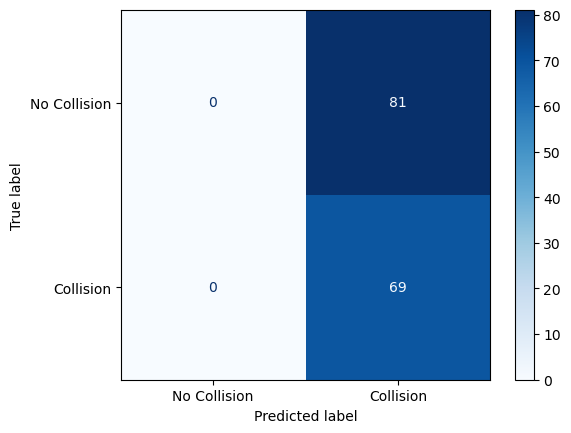

In [119]:
# Convert predictions to binary (0 or 1)
y_pred_binary = (y_pred_percentage > 0.5).astype(int)

# Compute accuracy
accuracy = accuracy_score(y_true, y_pred_binary)

print(f"Model Accuracy: {accuracy:.4f}")


# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_binary)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Collision", "Collision"])
disp.plot(cmap = "Blues", values_format = "d")